### Exercícios de fixação - Aula 02 - Preparacao_transformacao

1. Leia novamente a base `iris-with-errors.csv`, faça a limpeza dos dados e remova as duas últimas colunas.

In [114]:
import pandas as pd

data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris-with-errors.csv')
data.head(25)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


In [115]:
# Quantas linhas e colunas existem?
print(f'O número de linhas e colunas do dataset é: {data.shape[0]} linhas e {data.shape[1]} colunas')
print(80 *'-')

print("Colunas da base:")
print(data.columns)
print(80 *'-')

print("Tipos de dados:")
print(data.dtypes)
print(80 *'-')

print("Quantidade de valores ausentes por coluna:")
print(data.isna().sum())
print(80 *'-')

print("\nNúmero de linhas duplicadas:", data.duplicated().sum())

O número de linhas e colunas do dataset é: 25 linhas e 5 colunas
--------------------------------------------------------------------------------
Colunas da base:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')
--------------------------------------------------------------------------------
Tipos de dados:
sepal_length        str
sepal_width         str
petal_length    float64
petal_width         str
species             str
dtype: object
--------------------------------------------------------------------------------
Quantidade de valores ausentes por coluna:
sepal_length    2
sepal_width     0
petal_length    0
petal_width     1
species         0
dtype: int64
--------------------------------------------------------------------------------

Número de linhas duplicadas: 5


Como visto acima, a coluna *sepal_length*, *sepal_width* e *petal_width* estão com o tipo de dado errado e isso interfere em todas os passos de processamento. 
Além disso, há alguns dados ausentes e duplicados.

Para corrigir isso, usaremos alguns passos para limpeza:

Passo 1 - Remover dados ausentes

In [116]:
data_sem_nan = data.dropna()

print('Dimensão antes da remoção de valores ausentes:', data.shape)
print('Dimensão após a remoção de valores ausentes:', data_sem_nan.shape)   

data_sem_nan.head(25)

Dimensão antes da remoção de valores ausentes: (25, 5)
Dimensão após a remoção de valores ausentes: (22, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada


Apesar da remoção dos valores *Nan*, podemos perceber que ainda há valores *estranhos*, no caso, *?*.

Vamos tratar esses valores da sequinte forma:

1. converter o *?* em *NA* e;
2. fazer um `dropna()` do `pandas`.

In [117]:
data_sem_nan_ajustado = data_sem_nan.replace('?', pd.NA) # converte os ? para NaN
data_sem_nan_ajustado = data_sem_nan_ajustado.dropna() # remove as linhas com valores ausentes (NaN inseridos na linha anterior)

print('Dimensão antes da remoção de valores ausentes que eram ?:', data_sem_nan.shape)
print('Dimensão após a remoção de valores ausentes:', data_sem_nan_ajustado.shape) 

data_sem_nan_ajustado.head(25)

Dimensão antes da remoção de valores ausentes que eram ?: (22, 5)
Dimensão após a remoção de valores ausentes: (19, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa


Agora não há mais valores ausentes ou estranhos. 

Contudo, parecem haver algumas linhas duplicadas!

Passo 2 - Remover veriricar e remover dados duplicados.

Para isso usaremos a função `duplicate()` do `pandas`

In [118]:
# verifica as linhas duplicadas
linhas_duplicadas = data_sem_nan_ajustado.duplicated() # identifica as linhas duplicadas true or false
print('Número de linhas duplicadas:', linhas_duplicadas.sum())
linhas_duplicadas.head(25)

Número de linhas duplicadas: 5


0     False
1      True
3     False
4      True
6     False
7     False
8      True
10    False
11    False
12    False
13    False
14     True
15    False
16    False
17     True
18    False
19    False
20    False
22    False
dtype: bool

In [119]:
# remove as linhas duplicadas
data_sem_duplicatas = data_sem_nan_ajustado.drop_duplicates()
print('Dimensão antes da remoção de linhas duplicadas:', data_sem_nan_ajustado.shape)
print('Dimensão após a remoção de linhas duplicadas:', data_sem_duplicatas.shape)
print(80 *'-')

print("Tipos de dados:")
print(data.dtypes)
print(80 *'-')

# renomeia o dataset para facilitar a manipulação

data_limpo = data_sem_duplicatas.copy()
data_limpo.head(25)

Dimensão antes da remoção de linhas duplicadas: (19, 5)
Dimensão após a remoção de linhas duplicadas: (14, 5)
--------------------------------------------------------------------------------
Tipos de dados:
sepal_length        str
sepal_width         str
petal_length    float64
petal_width         str
species             str
dtype: object
--------------------------------------------------------------------------------


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
3,4.7,3.2,1.3,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa
16,4.8,3,1.4,0.1,setosa


Apesar dos dados parecerem limpos, tipo dos dados ainda não está adequado, pois ainda aparecem como str quando deveriam ser float. Isso impede realizar o cálcudo de estatisticas descritivas.

Vamos ajustar!

In [120]:
# Converte as colunas numéricas (que estão como str) para float
# valores inválidos, como "?", viram NaN automaticamente (errors='coerce')
cols_numericas = data_limpo.columns.drop('species')

data_limpo[cols_numericas] = data_limpo[cols_numericas].apply(pd.to_numeric, errors='coerce') 

print("Tipos de dados:")
print(data_limpo.dtypes)
print(80 *'-')

Tipos de dados:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
--------------------------------------------------------------------------------


Agora sim!!!

Vamos rever como o dataset ficou!!!

In [121]:
# Quantas linhas e colunas existem?
print(f'O número de linhas e colunas do dataset é: {data_limpo.shape[0]} linhas e {data_limpo.shape[1]} colunas')
print(80 *'-')

print("Colunas da base:")
print(data_limpo.columns)
print(80 *'-')

print("Tipos de dados:")
print(data_limpo.dtypes)
print(80 *'-')

print("Quantidade de valores ausentes por coluna:")
print(data_limpo.isna().sum())
print(80 *'-')

print("\nNúmero de linhas duplicadas:", data_limpo.duplicated().sum())

O número de linhas e colunas do dataset é: 14 linhas e 5 colunas
--------------------------------------------------------------------------------
Colunas da base:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')
--------------------------------------------------------------------------------
Tipos de dados:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
--------------------------------------------------------------------------------
Quantidade de valores ausentes por coluna:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
--------------------------------------------------------------------------------

Número de linhas duplicadas: 0


2. Leia novamente a base `iris-with-errors.csv` e substitua os valores ausentes pela **mediana** de cada atributo.

In [122]:
import pandas as pd

data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris-with-errors.csv')
data.head()

data_nan = data.replace('?', pd.NA) # converte os ? para NaN
data_nan.head()

print("Quantidade de valores ausentes por coluna antes da transformação:")
print(80 *'-')
print(data.isna().sum())
print(80 *'-')

print("Quantidade de valores ausentes por coluna após a transformação:")
print(80 *'-')
print(data_nan.isna().sum())

data_nan.head(25)

Quantidade de valores ausentes por coluna antes da transformação:
--------------------------------------------------------------------------------
sepal_length    2
sepal_width     0
petal_length    0
petal_width     1
species         0
dtype: int64
--------------------------------------------------------------------------------
Quantidade de valores ausentes por coluna após a transformação:
--------------------------------------------------------------------------------
sepal_length    3
sepal_width     1
petal_length    0
petal_width     2
species         0
dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,NaN,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


Como há uma coluna do tipo `string`, precisamos remover ela e, em seguida, usar a função `fillna()` do `pandas`.

In [123]:
atributos = data_nan.columns[:-1]

# Converte as colunas de atributos para valores numéricos.
data_nan[atributos] = data_nan[atributos].astype(float)

# Substitui os valores ausentes pela média de cada coluna.
data_media = data_nan.copy()
data_media[atributos] = data_media[atributos].fillna(data_media[atributos].median())
# data_media[atributos] = data_media[atributos].fillna(data_media[atributos].mean()) # outra opção é substituir pela média
# data_media[atributos] = data_media[atributos].fillna(-10) # outra opção é substituir por um valor fixo, como -10

data_media.head(25)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.10,3.50,1.4,0.2,duplicada
1,5.10,3.50,1.4,0.2,duplicada
2,5.05,3.00,1.4,0.2,setosa
3,4.70,3.20,1.3,0.2,setosa
4,5.10,3.50,1.4,0.2,duplicada
5,5.05,3.10,1.5,0.2,setosa
6,5.00,3.60,1.4,0.2,setosa
7,5.40,3.90,1.7,0.4,duplicada
8,5.40,3.90,1.7,0.4,duplicada
9,4.60,3.40,1.4,0.2,setosa


3. Considere a base `iris.csv`. Mostre o histograma de cada variável antes e depois da normalização.

In [124]:
import pandas as pd

data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv')
data.head(15)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### Normalização Min-Max

Como muitos algoritmos de ML são sensíveis a escala, iremos transformar/normalizar os dados para um intervalo fixo, geralmente \([0,1]\): Para isso, usaremos a equação abaixo que é executada pelo método `MinMaxScaler()` do `sklearn`.

$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$

Passo 1 - Separar os atributos (features) da classe (outcome)

In [125]:
import numpy as np

# Considera somente os atributos, ignorando a última coluna, que contém a classe.
X = np.array(data[data.columns[:-1]], dtype=float)
y = data[data.columns[-1]]

print("Dimensão da matriz de atributos:", X.shape)
print("Classes:", np.unique(y))

print(80 *'-')

for i in range(X.shape[1]):
    print(f"Coluna {i}: mínimo = {X[:, i].min():.2f}, máximo = {X[:, i].max():.2f}")

Dimensão da matriz de atributos: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------------------------------------
Coluna 0: mínimo = 4.30, máximo = 7.90
Coluna 1: mínimo = 2.00, máximo = 4.40
Coluna 2: mínimo = 1.00, máximo = 6.90
Coluna 3: mínimo = 0.10, máximo = 2.50


Repara que cada coluna tem um min-max!

Vamos normalizar os atributos para tratar isso!

In [126]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler(feature_range=(0, 1)) # Cria um escalador Min-Max [0, 1] 
X_minmax = scaler_minmax.fit_transform(X) # Aplica a transformação Min-Max aos dados

print("Dimensão da matriz de atributos após escalonamento:", X_minmax.shape) # não é pra mudar mesmo

print(80 *'-')

for i in range(X_minmax.shape[1]):
    print(f"Coluna {i}: mínimo = {X_minmax[:, i].min():.2f}, máximo = {X_minmax[:, i].max():.2f}")


Dimensão da matriz de atributos após escalonamento: (150, 4)
--------------------------------------------------------------------------------
Coluna 0: mínimo = 0.00, máximo = 1.00
Coluna 1: mínimo = 0.00, máximo = 1.00
Coluna 2: mínimo = 0.00, máximo = 1.00
Coluna 3: mínimo = 0.00, máximo = 1.00


Agora temos a matriz de atributos `X` com os dados originais e a matriz `X_minmax` com os dados normalizados.

Vamos verificar a distribuição por inspeção do histograma (não é para mudar!)

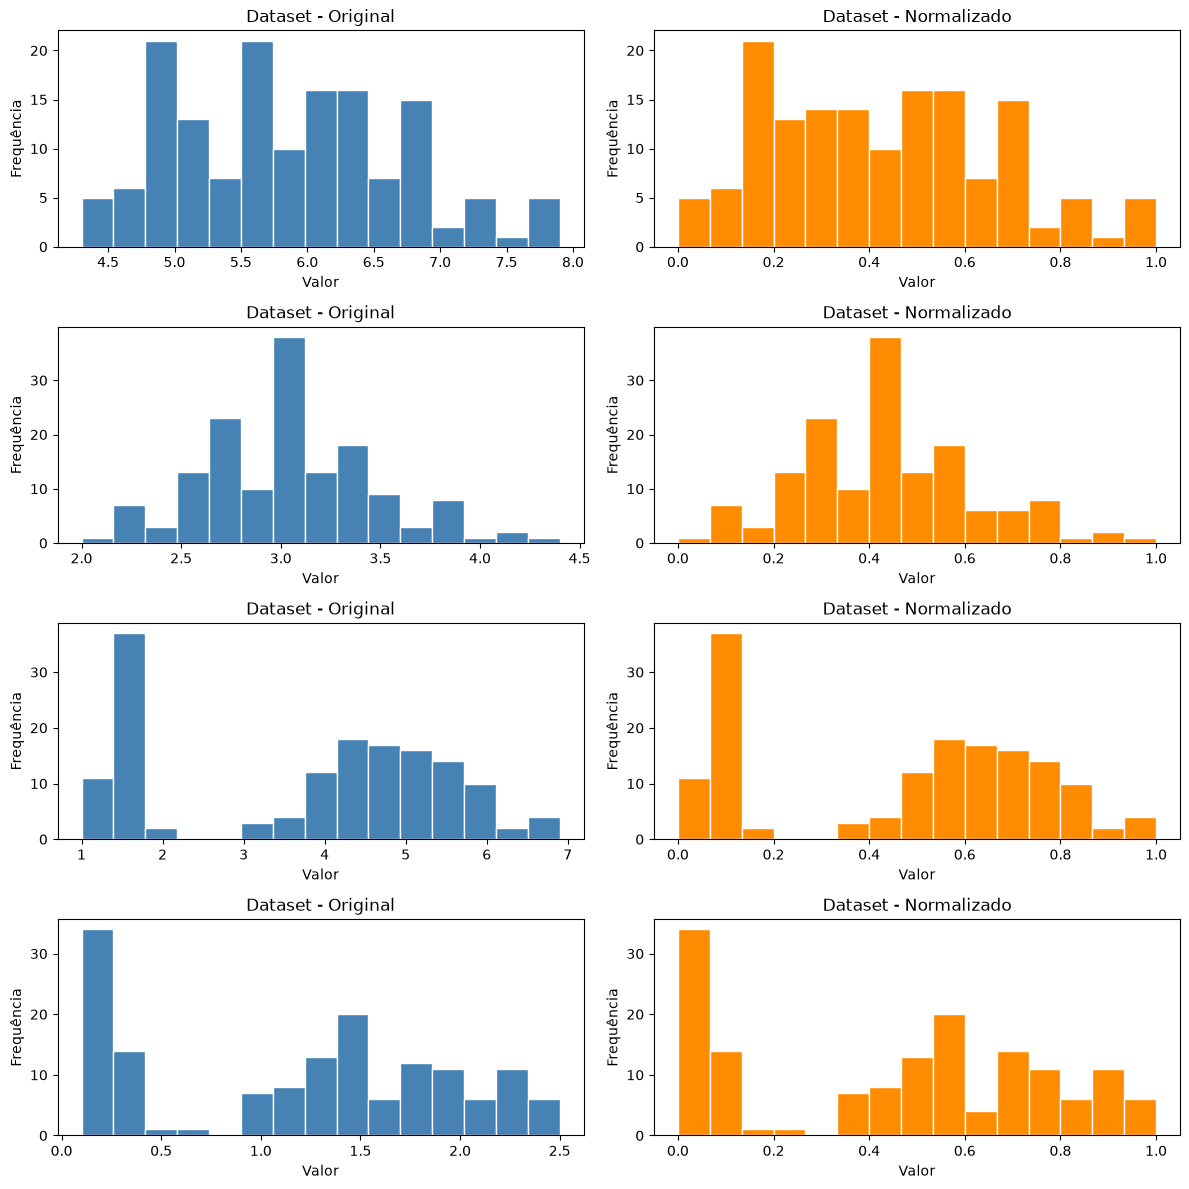

In [127]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(12, 12))

axes[0, 0].hist(X[:, 0], bins=15, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Dataset - Original')
axes[0, 0].set_xlabel('Valor')
axes[0, 0].set_ylabel('Frequência')

axes[0, 1].hist(X_minmax[:, 0], bins=15, color='darkorange', edgecolor='white')
axes[0, 1].set_title('Dataset - Normalizado')
axes[0, 1].set_xlabel('Valor')
axes[0, 1].set_ylabel('Frequência')

axes[1, 0].hist(X[:, 1], bins=15, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Dataset - Original')
axes[1, 0].set_xlabel('Valor')
axes[1, 0].set_ylabel('Frequência')

axes[1, 1].hist(X_minmax[:, 1], bins=15, color='darkorange', edgecolor='white')
axes[1, 1].set_title('Dataset - Normalizado')
axes[1, 1].set_xlabel('Valor')
axes[1, 1].set_ylabel('Frequência')

axes[2, 0].hist(X[:, 2], bins=15, color='steelblue', edgecolor='white')
axes[2, 0].set_title('Dataset - Original')
axes[2, 0].set_xlabel('Valor')
axes[2, 0].set_ylabel('Frequência')

axes[2, 1].hist(X_minmax[:, 2], bins=15, color='darkorange', edgecolor='white')
axes[2, 1].set_title('Dataset - Normalizado')
axes[2, 1].set_xlabel('Valor')
axes[2, 1].set_ylabel('Frequência')

axes[3, 0].hist(X[:, 3], bins=15, color='steelblue', edgecolor='white')
axes[3, 0].set_title('Dataset - Original')
axes[3, 0].set_xlabel('Valor')
axes[3, 0].set_ylabel('Frequência')

axes[3, 1].hist(X_minmax[:, 3], bins=15, color='darkorange', edgecolor='white')
axes[3, 1].set_title('Dataset - Normalizado')
axes[3, 1].set_xlabel('Valor')
axes[3, 1].set_ylabel('Frequência') 

plt.tight_layout()
plt.show()

4. Considere a base `iris.csv`. Mostre o histograma de cada variável antes e depois da padronização.

Agora iresmos transformar os dados para terem média zero e desvio padrão igual a um:

Para isso será utilizada o `Z-score` conforme equação descrita abaixo.

$
z = \frac{x - \mu}{\sigma}
$

Iremos implementar a padronização utilizando o método `StandardScaler()` do `sklearn`.

In [128]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Le o dataset iris.csv
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv')

# ignora a última coluna, que contém a classe.
X = np.array(data[data.columns[:-1]], dtype=float)
y = data[data.columns[-1]]

print("Dimensão da matriz de atributos:", X.shape)
print("Classes:", np.unique(y))

print(80 *'-')

for i in range(X.shape[1]):
    print(f"Coluna {i}: mínimo = {X[:, i].min():.2f}, máximo = {X[:, i].max():.2f}")

print(80 *'-')

scaler_standard = StandardScaler() # Cria um escalador padrão (z-score)
X_standard = scaler_standard.fit_transform(X) # Aplica a transformação padrão aos dados

print("Dimensão da matriz de atributos após padronização:", X_standard.shape) # não é pra mudar mesmo

print(80 *'-')

for i in range(X_standard.shape[1]):
    print(f"Coluna {i}: média = {X_standard[:, i].mean():.2f}, desvio padrão = {X_standard[:, i].std():.2f}")

Dimensão da matriz de atributos: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------------------------------------
Coluna 0: mínimo = 4.30, máximo = 7.90
Coluna 1: mínimo = 2.00, máximo = 4.40
Coluna 2: mínimo = 1.00, máximo = 6.90
Coluna 3: mínimo = 0.10, máximo = 2.50
--------------------------------------------------------------------------------
Dimensão da matriz de atributos após padronização: (150, 4)
--------------------------------------------------------------------------------
Coluna 0: média = -0.00, desvio padrão = 1.00
Coluna 1: média = -0.00, desvio padrão = 1.00
Coluna 2: média = 0.00, desvio padrão = 1.00
Coluna 3: média = -0.00, desvio padrão = 1.00


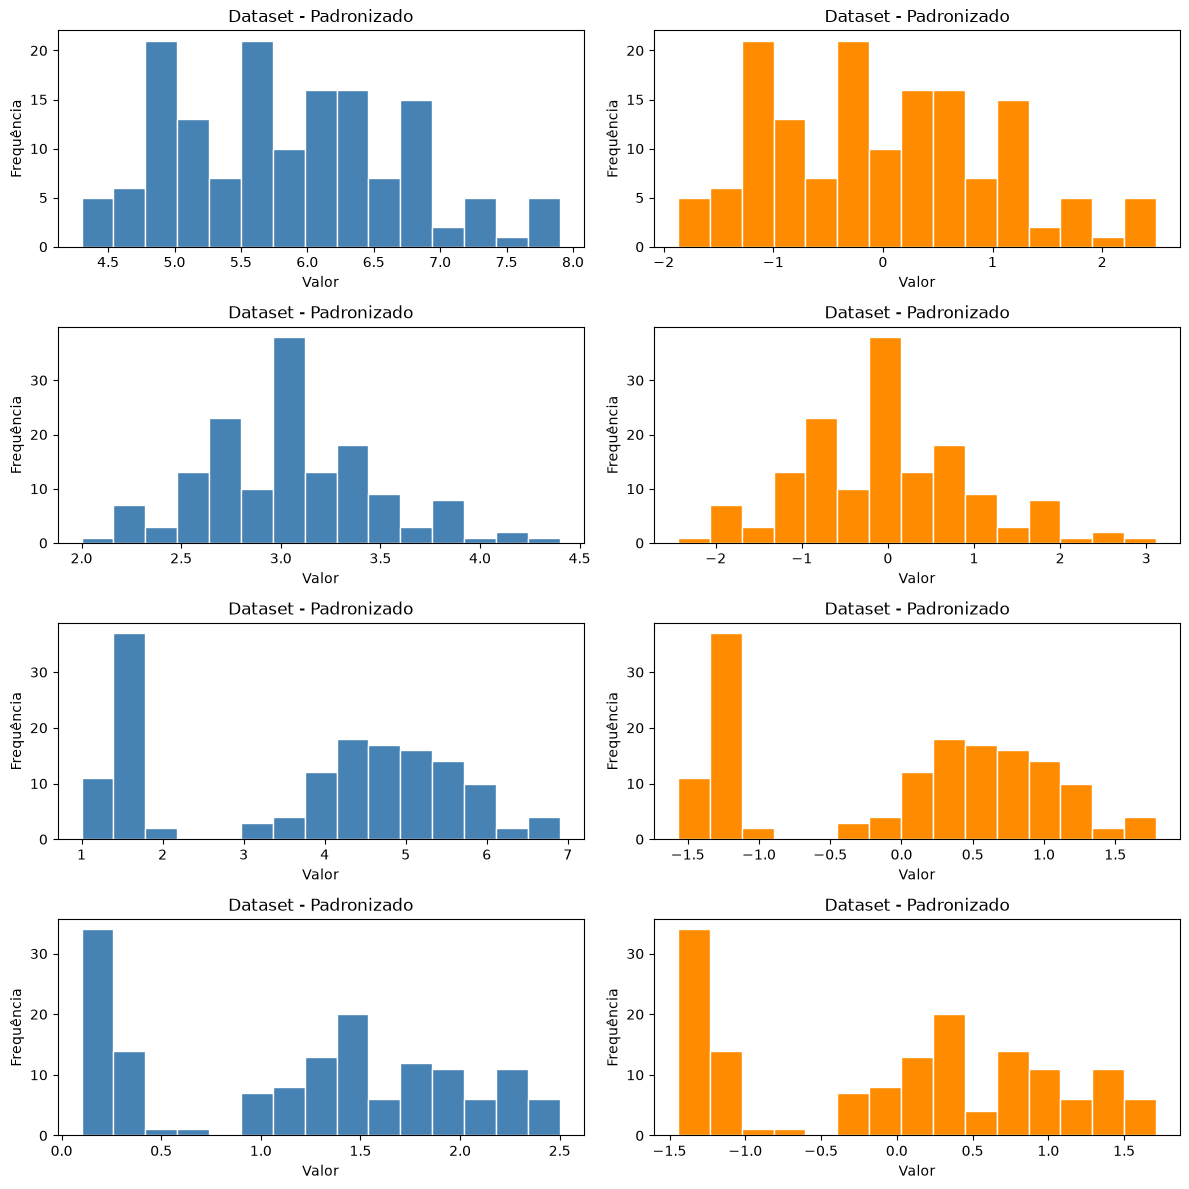

In [129]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(12, 12))

axes[0, 0].hist(X[:, 0], bins=15, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Dataset - Padronizado')
axes[0, 0].set_xlabel('Valor')
axes[0, 0].set_ylabel('Frequência')

axes[0, 1].hist(X_standard[:, 0], bins=15, color='darkorange', edgecolor='white')
axes[0, 1].set_title('Dataset - Padronizado')
axes[0, 1].set_xlabel('Valor')
axes[0, 1].set_ylabel('Frequência')

axes[1, 0].hist(X[:, 1], bins=15, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Dataset - Padronizado')
axes[1, 0].set_xlabel('Valor')
axes[1, 0].set_ylabel('Frequência')

axes[1, 1].hist(X_standard[:, 1], bins=15, color='darkorange', edgecolor='white')
axes[1, 1].set_title('Dataset - Padronizado')
axes[1, 1].set_xlabel('Valor')
axes[1, 1].set_ylabel('Frequência')

axes[2, 0].hist(X[:, 2], bins=15, color='steelblue', edgecolor='white')
axes[2, 0].set_title('Dataset - Padronizado')
axes[2, 0].set_xlabel('Valor')
axes[2, 0].set_ylabel('Frequência')

axes[2, 1].hist(X_standard[:, 2], bins=15, color='darkorange', edgecolor='white')
axes[2, 1].set_title('Dataset - Padronizado')
axes[2, 1].set_xlabel('Valor')
axes[2, 1].set_ylabel('Frequência')

axes[3, 0].hist(X[:, 3], bins=15, color='steelblue', edgecolor='white')
axes[3, 0].set_title('Dataset - Padronizado')
axes[3, 0].set_xlabel('Valor')
axes[3, 0].set_ylabel('Frequência')

axes[3, 1].hist(X_standard[:, 3], bins=15, color='darkorange', edgecolor='white')
axes[3, 1].set_title('Dataset - Padronizado')
axes[3, 1].set_xlabel('Valor')
axes[3, 1].set_ylabel('Frequência') 

plt.tight_layout()
plt.show()

5. Reamostre a base Iris selecionando 10 elementos de cada classe.

Essa técnica é útil para lidar com dataset desbalanceado!

In [130]:
import pandas as pd

data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv')

print("Dimensão da matriz de atributos:", X.shape)
print(80 *'-')

print("Classes:", data[data.columns[-1]].unique())
print(80 *'-')

print("Quantidade de amostras por classe:")
print(80 *'-')
print(data[data.columns[-1]].value_counts())

Dimensão da matriz de atributos: (150, 4)
--------------------------------------------------------------------------------
Classes: <StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str
--------------------------------------------------------------------------------
Quantidade de amostras por classe:
--------------------------------------------------------------------------------
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Como podemos observar, neste conjunto de dados, as classes estão balanceadas.

No entanto, suponha que as classes não estivessem balanceadas e fosse necessário realizar uma amostragem para obter a mesma quantidade de observações em cada classe.

A seguir, realizamos uma amostragem de 10 observações por classe.

In [131]:
N = 10  # Número de amostras a serem selecionadas de cada classe

X = np.array(data) # Matriz de características
cls = np.array(data[data.columns[-1]]) # Vetor de rótulos
classes_unicas = np.unique(cls)

amostras = []
for classe in classes_unicas:
    indices_classe = np.argwhere(cls == classe).ravel()
    indices_sorteados = np.random.choice(indices_classe, N, replace=False)
    amostras.append(X[indices_sorteados, :])

X_balanceado = np.vstack(amostras)

print("Dados obtidos a partir da amostragem:")
print(X_balanceado)

Dados obtidos a partir da amostragem:
[[5.1 3.7 1.5 0.4 'setosa']
 [4.9 3.1 1.5 0.1 'setosa']
 [4.6 3.1 1.5 0.2 'setosa']
 [5.2 4.1 1.5 0.1 'setosa']
 [5.0 3.4 1.6 0.4 'setosa']
 [5.4 3.4 1.5 0.4 'setosa']
 [5.4 3.9 1.3 0.4 'setosa']
 [4.8 3.0 1.4 0.1 'setosa']
 [5.0 3.2 1.2 0.2 'setosa']
 [4.8 3.1 1.6 0.2 'setosa']
 [6.0 3.4 4.5 1.6 'versicolor']
 [5.9 3.0 4.2 1.5 'versicolor']
 [5.6 3.0 4.1 1.3 'versicolor']
 [5.7 2.8 4.1 1.3 'versicolor']
 [6.3 3.3 4.7 1.6 'versicolor']
 [5.6 2.9 3.6 1.3 'versicolor']
 [5.7 2.6 3.5 1.0 'versicolor']
 [6.7 3.0 5.0 1.7 'versicolor']
 [5.2 2.7 3.9 1.4 'versicolor']
 [5.7 2.8 4.5 1.3 'versicolor']
 [6.7 3.3 5.7 2.5 'virginica']
 [4.9 2.5 4.5 1.7 'virginica']
 [7.7 3.8 6.7 2.2 'virginica']
 [6.4 2.8 5.6 2.1 'virginica']
 [6.3 3.4 5.6 2.4 'virginica']
 [6.2 3.4 5.4 2.3 'virginica']
 [6.2 2.8 4.8 1.8 'virginica']
 [7.2 3.0 5.8 1.6 'virginica']
 [6.3 2.9 5.6 1.8 'virginica']
 [7.7 2.8 6.7 2.0 'virginica']]


In [132]:
X_df = pd.DataFrame(X_balanceado, columns=data.columns)

print("Dimensão da matriz de atributos amostrada:", X_df.shape)
print(80 *'-')

print("Classes:", X_df[X_df.columns[-1]].unique())
print(80 *'-')

print("Quantidade de amostras por classe:")
print(80 *'-')
print(X_df[X_df.columns[-1]].value_counts())

Dimensão da matriz de atributos amostrada: (30, 5)
--------------------------------------------------------------------------------
Classes: <StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str
--------------------------------------------------------------------------------
Quantidade de amostras por classe:
--------------------------------------------------------------------------------
species
setosa        10
versicolor    10
virginica     10
Name: count, dtype: int64


Finalizado!

Saulo Gil

😉